# Лабораторная работа 2. Ассоциативные правила

## Описание работы

**Цель работы:** исследование методов анализа ассоциативных правил.

**Постановка задачи:**

В файле "ass_rules.pdf" находится программный код для выполнения данной работы. Провести исследование методов анализа ассоциативных правил на датасете с Kaggle:

1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ). Данные должны представлять собой информацию о купленных вместе товарах .

2. Привести описание данных из датасета: график вывода длин транзакций, список уникальных товаров и др. 

3. Алгоритм Apriori: выполнить анализ ассоциативных правил при помощи алгоритма Apriori с изначальными условиями в соответствии с вариантом задания. Проанализировать полученные результаты, выделив полезные и тривиальные правила, и оценив значение достоверности, лифта правил. Провести оценку влияния параметров алгоритма на получаемые правила (на количество правил и метрики).

4. Алгоритм FPG: провести анализ правил, используя алгоритм FPG. В отчете привести правила, получившиеся в результате использования данного алгоритма.

5. Алгоритмически определить минимальные значения поддержки для составления правил из 1, 2, и т.д. объектов в одном из алгоритмов.

6. Последовательно меняя параметры (значения поддержки и достоверности) одного из алгоритмов получить наборы ассоциативных правил. Сделать выводы на основе проведенных экспериментов.

7. Проанализировать получающийся в результате работы программы граф. Объяснить, какую информацию можно из него извлечь.

8. Предложить и реализовать свой способ визуализации ассоциативных правил и метрик.

## Ход работы

### 1 Загрузка данных

На первом этапе работы был загружен датасет, содержащий сведения о транзакциях, где каждая строка отражает набор тв шоу.

In [1144]:
import pandas as pd

df = pd.read_csv('TV_Shows.csv', header = None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,Cobra Kai,Lupin,12 Monkeys,Sherlock,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Lost,Jack Ryan,The Flash,Game of thrones,House of Cards,12 Monkeys,Vikings,Fringe,The Mentalist,The Alienist,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sex Education,Dr. House,Kingdom,The Walking Dead,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ozark,Sex Education,Constantine,Preacher,Vikings,The Tick,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Naruto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2 Анализ данных

**О датасете:** Используемый в работе датасет содержит информацию о телешоу, которые пользователи просматривали совместно.

> Для наглядного анализа данных построена гистограмма, показывающая, как распределено количество телешоу в транзакциях



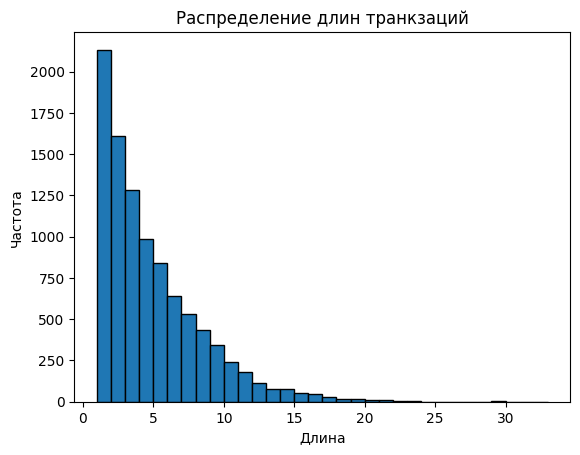

In [1145]:
import matplotlib.pyplot as plt

df.describe()

tr_len = df.notnull().sum(axis=1)

plt.hist(tr_len, bins=range(1, max(tr_len)+2), edgecolor='black')
plt.title('Распределение длин транкзаций')
plt.xlabel('Длина')
plt.ylabel('Частота')
plt.show()


> Далее избавимся от nan значений

In [1146]:
np_data = df.to_numpy()
np_data = [[elem for elem in row if isinstance(elem,str)] for row in np_data]

Данные были преобразованы в бинарную матрицу, где каждая строка представляет транзакцию, а столбцы — телешоу. Значения показывают, присутствует ли конкретное шоу в транзакции.

In [1147]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_data = te.fit_transform(np_data)

data = pd.DataFrame(te_data, columns=te.columns_)

data


,12 Monkeys,24,Absentia,Alice in Borderland,Altered Carbon,American Gods,Another Life,Archer,Arrow,Atypical,...,True Detective,Two and a half men,Upload,Vikings,Watchmen,Westworld,White Collar,X-Files,You,Young Sheldon
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9685,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
9686,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
9687,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
9688,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Получим список уникальных телешоу и сколько раз они встречаются

In [1148]:
data.sum().sort_values(ascending=False).head(10)

unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(unique_items)

{'Grimm', 'Dark', 'Outer Banks', 'Absentia', 'Watchmen', 'Friends', '12 Monkeys', 'Mare of Easttown', 'House of Cards', 'Schitts Creek', 'Cobra Kai', 'Only Murders in the building', 'Perception', 'Ozark', 'Prison Break', 'Punisher', 'The Big Bang Theory', 'Outlander', 'Chernobyl', 'Banshee', 'Lucifer', 'Daredevil', 'Sex Education', 'The Alienist', 'Space Force', 'Game of thrones', 'The Outsider', 'The Night Manager', 'How to get away with murder', 'Billions', 'Hunters', 'Squid Game', 'Doctor Who', 'Suits', 'Bojack Horseman', 'Vikings', 'Queen of the South', 'Alice in Borderland', 'Mirzapur', 'Person of Interest', 'The 100', 'Brooklyn Nine Nine', 'Sense 8', 'Sons of Anarchy', 'Black Clover', 'You', 'Better Call Saul', 'Startup', 'Supernatural', 'Elementary', 'Spartacus', 'Kingdom', 'The Office', 'Love Death Robots', 'The Wire', 'Lost in Space', 'Loki', 'The Good Doctor', 'Lupin', 'Berlin Station', 'Peaky Blinders', 'The Vampire Diaries', '24', 'The Nevers', 'Death Note', 'Westworld', 'R

### 3 Алгоритм Apriori
#### 3.1 Анализ ассоциативных правил с изначальными условиями в соответствии с вариантом задания. 
Начальные параметры: поддержка 0.02 и достоверность 0.3. 

In [1149]:
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns

frequent_itemsets = apriori(data, min_support=0.02, use_colnames = True)
rules = association_rules(frequent_itemsets,min_threshold=0.3)
print(f'Количество правил: {len(rules)}')


Количество правил: 39


Выведем топ популярных телешоу

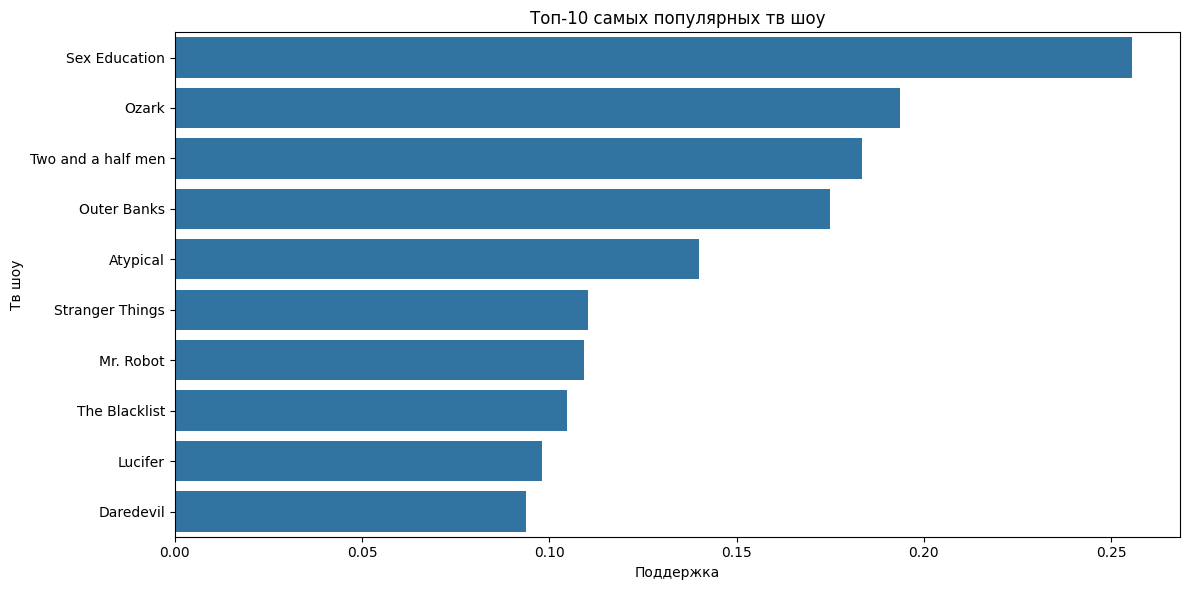

     support            itemsets
39  0.255624       Sex Education
35  0.193705               Ozark
56  0.183591  Two and a half men
34  0.175026         Outer Banks
5   0.139938            Atypical
42  0.110423     Stranger Things
31  0.109391           Mr. Robot
45  0.104850       The Blacklist
29  0.097936             Lucifer
13  0.093911           Daredevil


In [1150]:
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ' → '.join(list(x)))
top_shows = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x='support', y='itemsets', data=top_shows)
plt.title('Топ-10 самых популярных тв шоу')
plt.xlabel('Поддержка')
plt.ylabel('Тв шоу')
plt.tight_layout()
plt.show()
print(top_shows)

В предоставленных данных видно, что центральными сериалами являются «Sex Education», «Ozark», «Two and a Half Men», «Outer Banks» и «Atypical». «Sex Education» занимает лидирующую позицию по support (25,5%), что свидетельствует о высокой популярности среди пользователей и делает его ядром для построения правил рекомендаций.

Выведим полученные правила

In [1151]:
rules.iloc[:,0:7].sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
34,"(Ozark, Atypical)",(Sex Education),0.043756,0.255624,0.022394,0.511792,2.002127
4,(Berlin Station),(Sex Education),0.055521,0.255624,0.027554,0.496283,1.941452
18,(Jack Ryan),(Sex Education),0.053767,0.255624,0.026419,0.491363,1.922206
37,"(Ozark, Mr. Robot)",(Sex Education),0.047575,0.255624,0.023117,0.485900,1.900837
13,(Dr. House),(Sex Education),0.063571,0.255624,0.030134,0.474026,1.854385
38,"(Sex Education, Mr. Robot)",(Ozark),0.048916,0.193705,0.023117,0.472574,2.439659
15,(Family Guy),(Sex Education),0.071517,0.255624,0.032301,0.451659,1.766887
21,(Mr. Robot),(Sex Education),0.109391,0.255624,0.048916,0.447170,1.749324
20,(Mr. Robot),(Ozark),0.109391,0.193705,0.047575,0.434906,2.245198
9,(Deception),(Sex Education),0.048297,0.255624,0.020537,0.425214,1.663432


При применении алгоритма с исходными параметрами было получено большое количество ассоциативных правил между телешоу. Чтобы выделить полезные и тривиальные правила, придется проанализировать все варианты, поэтому в дальнейшем будем уменьшать значения поддержки и достоверности.


#### 3.2 Изменение параметров алгоритма

Увеличим значение поддержки до 3% и достоверность до 30%:

In [1152]:
frequent_itemsets = apriori(data, min_support=0.03, use_colnames = True)
rules = association_rules(frequent_itemsets,min_threshold=0.3)
print(f'Количество правил: {len(rules)}')
rules.iloc[:,0:7].sort_values(by='confidence', ascending=False)

Количество правил: 16


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
6,(Dr. House),(Sex Education),0.063571,0.255624,0.030134,0.474026,1.854385
7,(Family Guy),(Sex Education),0.071517,0.255624,0.032301,0.451659,1.766887
9,(Mr. Robot),(Sex Education),0.109391,0.255624,0.048916,0.447170,1.749324
8,(Mr. Robot),(Ozark),0.109391,0.193705,0.047575,0.434906,2.245198
13,(The Blacklist),(Sex Education),0.104850,0.255624,0.042312,0.403543,1.578658
1,(Atypical),(Sex Education),0.139938,0.255624,0.056140,0.401180,1.569412
5,(Demon Slayer),(Sex Education),0.075439,0.255624,0.030134,0.399453,1.562656
10,(Ozark),(Sex Education),0.193705,0.255624,0.075129,0.387853,1.517277
14,(The Walking Dead),(Sex Education),0.088648,0.255624,0.033540,0.378347,1.480089
2,(Cobra Kai),(Sex Education),0.083075,0.255624,0.030650,0.368944,1.443306


После изменения параметров алгоритма ассоциативного анализа, при увеличении минимальной поддержки до 3% и порога достоверности до 30%, были получены более устойчивые и значимые правила.
Если ориентироваться на практическую полезность правил, нужно выбирать те, которые имеют confidence ≥ 0.35 и lift ≥ 1.5, то есть достаточно достоверные и сильно увеличивающие вероятность просмотра consequent.
Тогда получим следующие правила:
1. **Dr. House → Sex Education**  
   Confidence: 0.474, Lift: 1.854  
   Почти половина зрителей «Dr. House» также смотрят «Sex Education».

2. **Family Guy → Sex Education**  
   Confidence: 0.452, Lift: 1.767  
   Смотрят «Family Guy» — высокая вероятность перехода к «Sex Education».

3. **Mr. Robot → Sex Education**  
   Confidence: 0.447, Lift: 1.749  
   Сильная ассоциация между «Mr. Robot» и «Sex Education».

4. **Mr. Robot → Ozark**  
   Confidence: 0.435, Lift: 2.245  
   Очень сильная нишевая ассоциация: зрители «Mr. Robot» более чем в два раза чаще смотрят «Ozark».

5. **The Blacklist → Sex Education**  
   Confidence: 0.404, Lift: 1.579  
   Значимое правило для рекомендаций на «Sex Education».

6. **Atypical → Sex Education**  
   Confidence: 0.401, Lift: 1.569  
   Умеренно сильное правило, хорошо для расширения аудитории.

7. **Ozark → Sex Education**  
   Confidence: 0.388, Lift: 1.517  
   Популярное правило для массовых рекомендаций.

8. **Atypical → Ozark**  
   Confidence: 0.313, Lift: 1.614  
   Несмотря на чуть ниже confidence, lift достаточно высокий для нишевых рекомендаций.

9. **Demon Slayer → Sex Education**  
   Confidence: 0.399, Lift: 1.563  
   Умеренно полезное правило для кросс-рекомендаций.

10. **The Blacklist → Ozark**  
    Confidence: 0.342, Lift: 1.763  
    Хорошее правило для целевой аудитории «Ozark».

Если мы еще будем увеличивать один из параметров, то правила будут ещё меньше, почти исключительно для самых популярных сериалов.



#### 3.3 График достоверности и граф правил

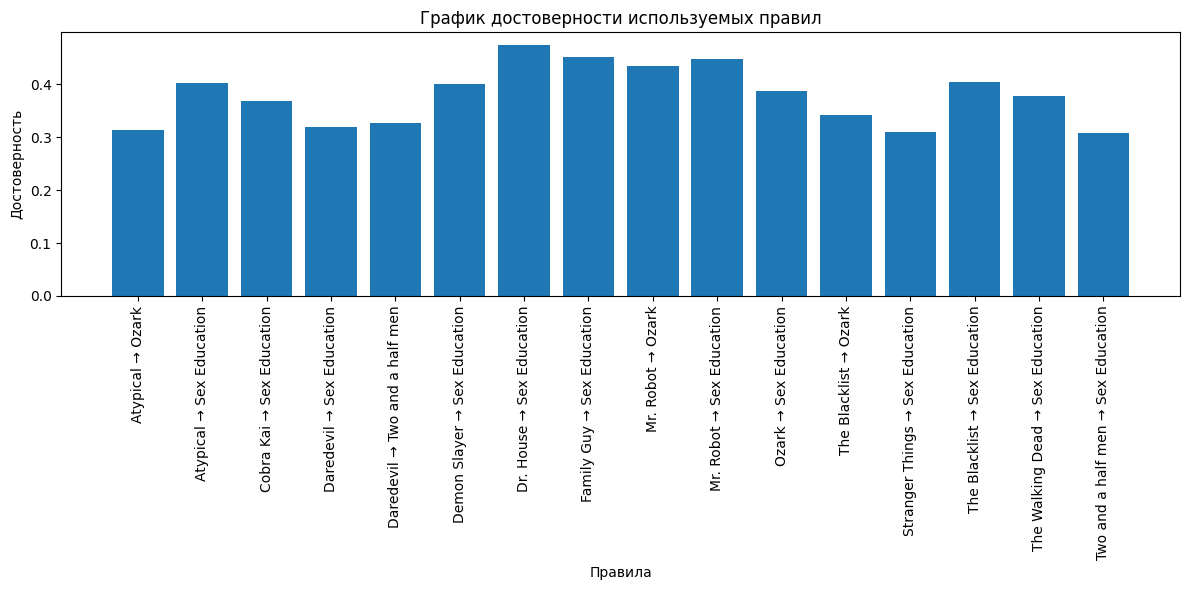

In [1153]:
rules['antecedents'] =  rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules['confidence'].to_list()

rules_labels = [f"{products_1} → {products_2}" for products_1, products_2 in zip(products_1, products_2)]
plt.figure(figsize=(12, 6))
plt.bar(rules_labels, confidence)
plt.xlabel('Правила')
plt.ylabel('Достоверность')
plt.xticks(rotation=90)
plt.title('График достоверности используемых правил')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11184\2267894299.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


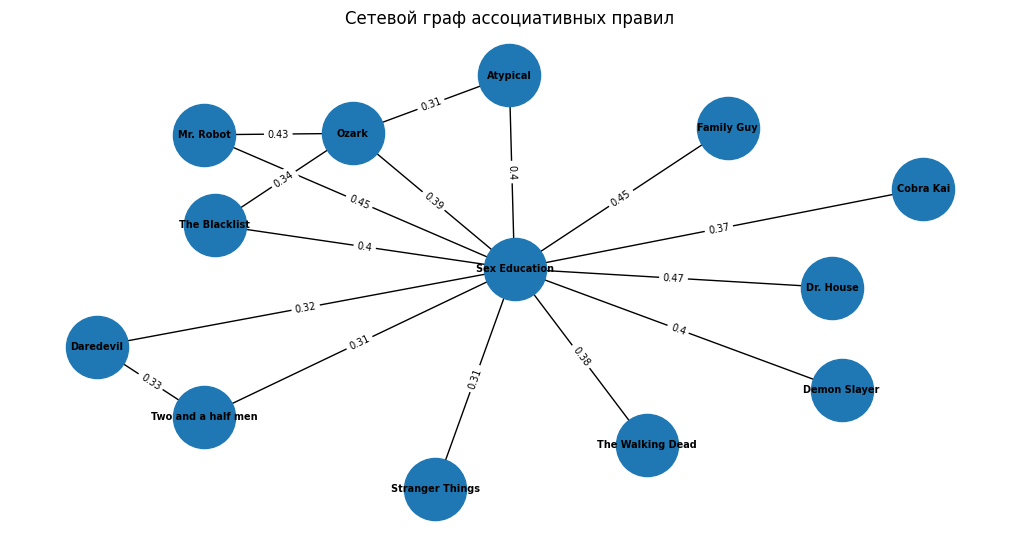

In [1154]:
import networkx as nx
G = nx.Graph()
for product in rules["antecedents"]:
    G.add_node(product)
for product in rules["consequents"]:
    G.add_node(product)
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=round(row['confidence'],2))
pos = nx.spring_layout(G)
plt.figure(figsize=(10,5))
nx.draw(G, pos,  with_labels=True, node_size=2000, font_size=7, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title('Сетевой граф ассоциативных правил')
plt.tight_layout()
plt.show()

На графике представлены значения достоверности для выявленных ассоциативных правил между сериалами. Видно, что все правила обладают средними значениями достоверности — она варьируется примерно от 0.3 до 0.45, что говорит о наличии устойчивой, хотя и не максимальной взаимосвязи между интересами зрителей. Наибольшую достоверность демонстрирует правило, связывающее «Доктор Хаус» с «Sex Education»: вероятность того, что среди зрителей первого сериала окажутся и поклонники второго, превышает 45%.

Наблюдается определённая тенденция: сериалы, относящиеся к популярным подростковым драмам и комедиям («Sex Education», «Family Guy», «Demon Slayer» и т.д.), формируют наиболее выраженные и логичные правила. Это связано с тем, что данные проекты часто смотрят одни и те же пользователи, что отражает закономерные интересы целевой аудитории. Более низкие значения достоверности характерны для более разрозненных сочетаний («Atypical → Ozark» и др.), где связь между сериалами менее очевидна, но всё же заметна в пользовательских предпочтениях.

На графе ассоциативных правил выделяется «Sex Education» — этот сериал чаще всего выступает как "правый" элемент в правилах, то есть к его просмотру приводят различные комбинации других сериалов. Наиболее прочные ассоциации наблюдаются между «Sex Education» и такими проектами, как «Доктор Хаус», «Family Guy» и «Demon Slayer», что подтверждает высокую вероятность их совместного просмотра.

Также заметны устойчивые связи между такими сериалами, как «Mr. Robot» и «Ozark», «The Blacklist» и «Sex Education».

#### Алгоритмически определить минимальные значения поддержки для составления правил из 1, 2, и т.д. объектов в одном из алгоритмов.

In [1155]:
df1 = apriori(data, min_support=0.03, use_colnames = True)
df1['length'] = df1['itemsets'].apply(lambda x: len(x))
print(df1.sort_values(by='support'))
min_support_by_len = df1.groupby('length')['support'].min()

print("Минимальные значения поддержки по длинам наборов:")
print(min_support_by_len)



     support                       itemsets  length
49  0.030031     (Sex Education, Daredevil)       2
38  0.030031            (The Night Manager)       1
52  0.030134     (Sex Education, Dr. House)       2
51  0.030134  (Sex Education, Demon Slayer)       2
14  0.030650          (Designated Survivor)       1
..       ...                            ...     ...
3   0.139938                     (Atypical)       1
26  0.175026                  (Outer Banks)       1
42  0.183591           (Two and a half men)       1
27  0.193705                        (Ozark)       1
31  0.255624                (Sex Education)       1

[66 rows x 3 columns]
Минимальные значения поддержки по длинам наборов:
length
1    0.030031
2    0.030031
Name: support, dtype: float64


### 3.4 Визуализации ассоциативных правил и метрик
Для визуализации ассоциативных правил удобно использовать heat map, где на осях X и Y откладываются antecedents и consequents, а цвет отражает показатель confidence или lift. Это позволяет быстро увидеть, какие пары сериалов связаны сильнее.

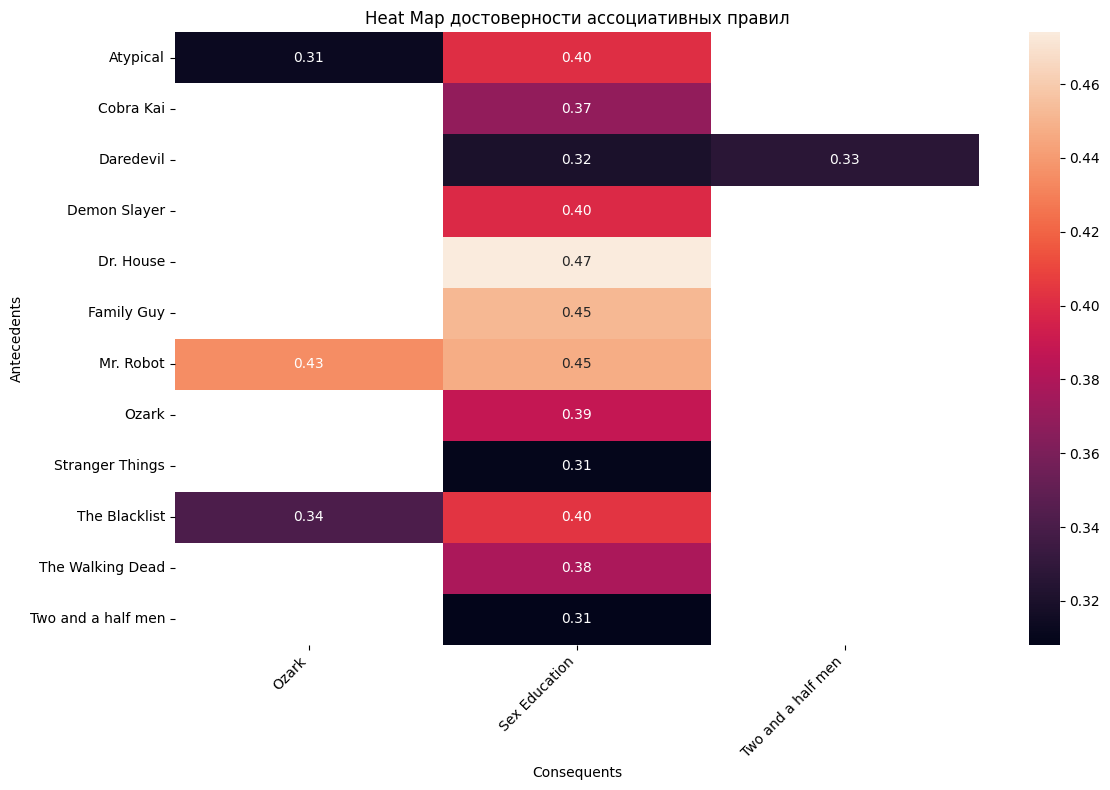

consequents,Ozark,Sex Education,Two and a half men
antecedents,,,
Atypical,0.312684,0.401180,NaN
Cobra Kai,NaN,0.368944,NaN
Daredevil,NaN,0.319780,0.326374
Demon Slayer,NaN,0.399453,NaN
Dr. House,NaN,0.474026,NaN
Family Guy,NaN,0.451659,NaN
Mr. Robot,0.434906,0.447170,NaN
Ozark,NaN,0.387853,NaN
Stranger Things,NaN,0.309346,NaN


In [1156]:
heat_data = rules.pivot(index='antecedents', columns='consequents', values='confidence')

plt.figure(figsize=(12,8))
sns.heatmap(heat_data, annot=True,  fmt=".2f",)
plt.title('Heat Map достоверности ассоциативных правил')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
heat_data

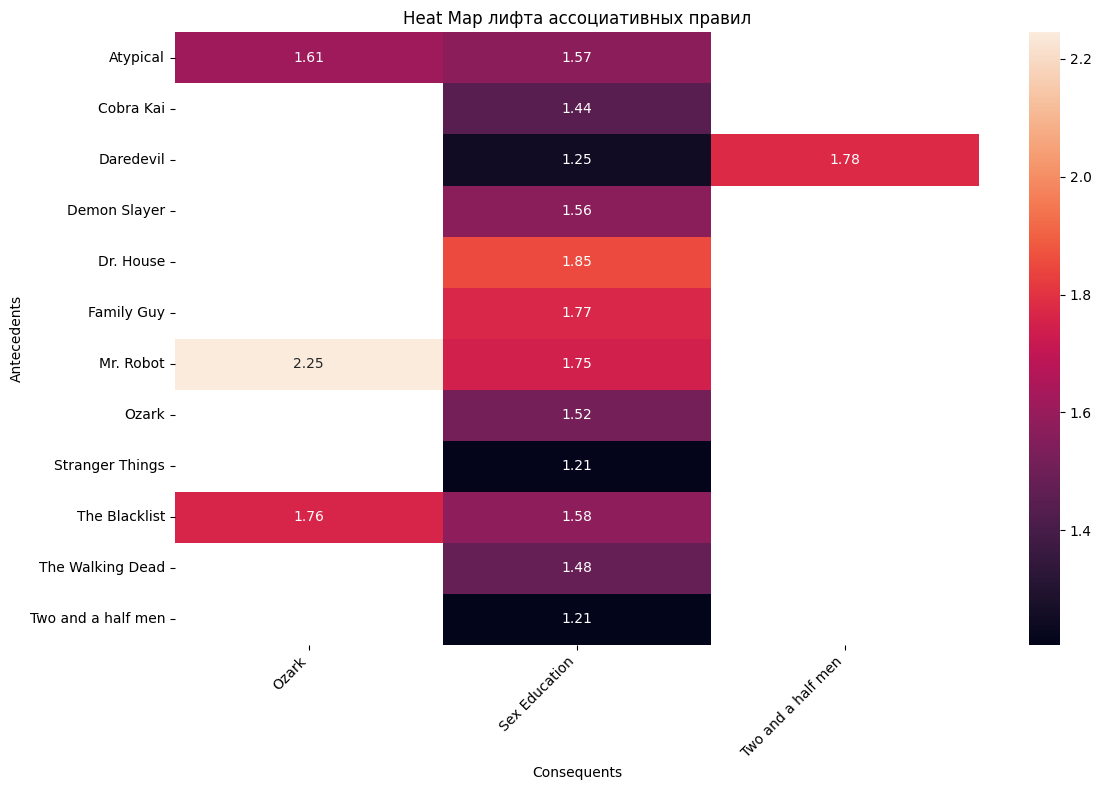

consequents,Ozark,Sex Education,Two and a half men
antecedents,,,
Atypical,1.614231,1.569412,NaN
Cobra Kai,NaN,1.443306,NaN
Daredevil,NaN,1.250977,1.777718
Demon Slayer,NaN,1.562656,NaN
Dr. House,NaN,1.854385,NaN
Family Guy,NaN,1.766887,NaN
Mr. Robot,2.245198,1.749324,NaN
Ozark,NaN,1.517277,NaN
Stranger Things,NaN,1.210158,NaN


In [1157]:
heat_data = rules.pivot(index='antecedents', columns='consequents', values='lift')

plt.figure(figsize=(12,8))
sns.heatmap(heat_data, annot=True,  fmt=".2f",)
plt.title('Heat Map лифта ассоциативных правил')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
heat_data

Тепловая карта наглядно демонстрирует, для каких ассоциативных правил значения лифта самые высокие.

### 4 Алгоритм FPG

#### 4.1 Анализ ассоциативных правил с изначальными условиями в соответствии с вариантом задания. 
Начальные параметры: поддержка 0.02 и достоверность 0.3. 

In [1158]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(data, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, min_threshold=0.3)
print(f'Количество правил: {len(rules)}')
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ' → '.join(list(x)))




Количество правил: 39


Выведем полученные правила

In [1159]:
rules.iloc[:,0:7].sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
13,"(Ozark, Atypical)",(Sex Education),0.043756,0.255624,0.022394,0.511792,2.002127
25,(Berlin Station),(Sex Education),0.055521,0.255624,0.027554,0.496283,1.941452
4,(Jack Ryan),(Sex Education),0.053767,0.255624,0.026419,0.491363,1.922206
37,"(Ozark, Mr. Robot)",(Sex Education),0.047575,0.255624,0.023117,0.485900,1.900837
7,(Dr. House),(Sex Education),0.063571,0.255624,0.030134,0.474026,1.854385
38,"(Sex Education, Mr. Robot)",(Ozark),0.048916,0.193705,0.023117,0.472574,2.439659
28,(Family Guy),(Sex Education),0.071517,0.255624,0.032301,0.451659,1.766887
35,(Mr. Robot),(Sex Education),0.109391,0.255624,0.048916,0.447170,1.749324
34,(Mr. Robot),(Ozark),0.109391,0.193705,0.047575,0.434906,2.245198
33,(Deception),(Sex Education),0.048297,0.255624,0.020537,0.425214,1.663432


При применении алгоритма с исходными параметрами было получено большое количество ассоциативных правил между телешоу. Чтобы выделить полезные и тривиальные правила, придется проанализировать все варианты, поэтому в дальнейшем будем уменьшать значения поддержки и достоверности.


#### 4.2 Изменение параметров алгоритма

Увеличим значение поддержки до 3% и достоверность до 40%:

In [1160]:
frequent_itemsets = apriori(data, min_support=0.04, use_colnames = True)
rules = association_rules(frequent_itemsets,min_threshold=0.3)
print(f'Количество правил: {len(rules)}')
rules.iloc[:,0:7].sort_values(by='confidence', ascending=False)

Количество правил: 7


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
3,(Mr. Robot),(Sex Education),0.109391,0.255624,0.048916,0.447170,1.749324
2,(Mr. Robot),(Ozark),0.109391,0.193705,0.047575,0.434906,2.245198
5,(The Blacklist),(Sex Education),0.104850,0.255624,0.042312,0.403543,1.578658
1,(Atypical),(Sex Education),0.139938,0.255624,0.056140,0.401180,1.569412
4,(Ozark),(Sex Education),0.193705,0.255624,0.075129,0.387853,1.517277
0,(Atypical),(Ozark),0.139938,0.193705,0.043756,0.312684,1.614231
6,(Two and a half men),(Sex Education),0.183591,0.255624,0.056553,0.308038,1.205043


Полезные правила ассоциации

На основе анализа правил ассоциации были выявлены наиболее значимые связи между сериалами, которые могут использоваться для рекомендаций. Оценка правил проводилась по показателям **confidence** и **lift**, где confidence отражает достоверность правила, а lift — силу ассоциации по сравнению с случайным совпадением.

Топ полезных правил:

1. **Mr. Robot → Sex Education**  
   - Confidence: 0.447, Lift: 1.749  
   - Почти половина зрителей «Mr. Robot» также смотрят «Sex Education». Правило полезно для таргетированных рекомендаций аудитории драм и подростковых шоу.

2. **Mr. Robot → Ozark**  
   - Confidence: 0.435, Lift: 2.245  
   - Очень сильная нишевая связь: зрители «Mr. Robot» в 2,25 раза чаще смотрят «Ozark» по сравнению со средним пользователем. Отлично подходит для узконаправленных рекомендаций.

3. **The Blacklist → Sex Education**  
   - Confidence: 0.404, Lift: 1.579  
   - Значимое правило для расширения аудитории «Sex Education» среди любителей триллеров и криминальных драм.

4. **Atypical → Sex Education**  
   - Confidence: 0.401, Lift: 1.569  
   - Ассоциация между сериалами подростковой и социальной тематики.

5. **Ozark → Sex Education**  
   - Confidence: 0.388, Lift: 1.517  
   - Массовая рекомендация: почти 39% зрителей «Ozark» также выбирают «Sex Education».

6. **Atypical → Ozark**  
   - Confidence: 0.313, Lift: 1.614  
   - Правило для более узкой аудитории: зрители «Atypical» часто смотрят «Ozark».

7. **Two and a Half Men → Sex Education**  
   - Confidence: 0.308, Lift: 1.205  
   - Слабее по lift, подходит для массовых рекомендаций аудитории ситкомов.

**Вывод:**  
Наиболее полезные правила — это те, где **confidence > 0.4** и **lift > 1.5**, так как они показывают как массовые, так и нишевые интересы пользователей. Правила с меньшим lift можно использовать для расширения охвата рекомендаций.


41


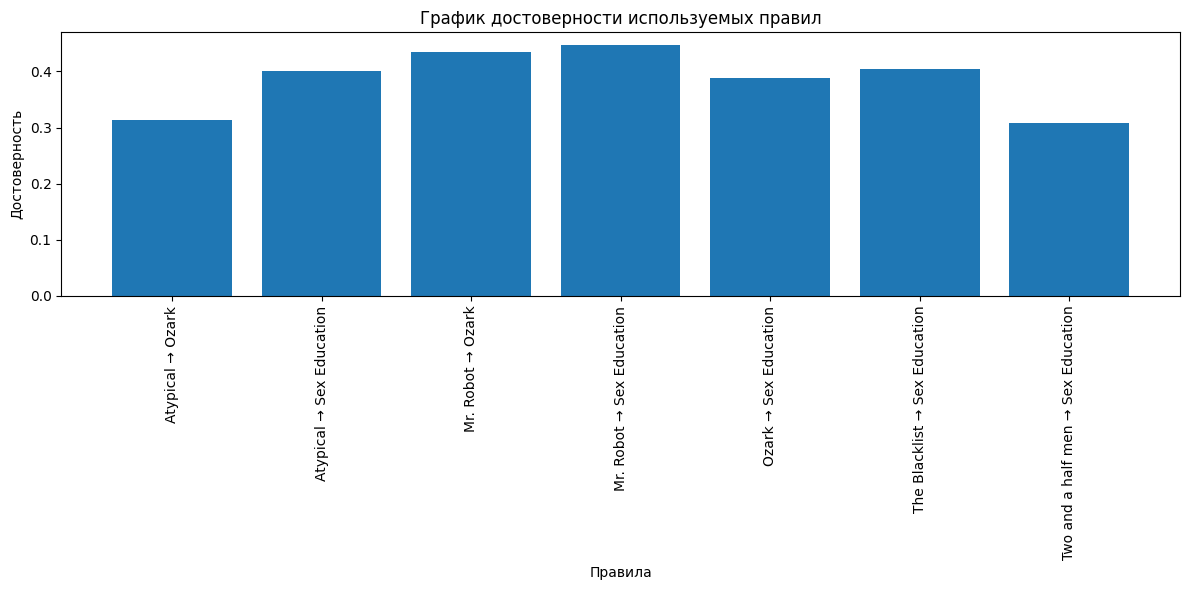

In [1161]:
print(len(frequent_itemsets))
rules['antecedents'] =  rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules['confidence'].to_list()

rules_labels = [f"{products_1} → {products_2}" for products_1, products_2 in zip(products_1, products_2)]
plt.figure(figsize=(12, 6))
plt.bar(rules_labels, confidence)
plt.xlabel('Правила')
plt.ylabel('Достоверность')
plt.xticks(rotation=90)
plt.title('График достоверности используемых правил')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_11184\3035002643.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


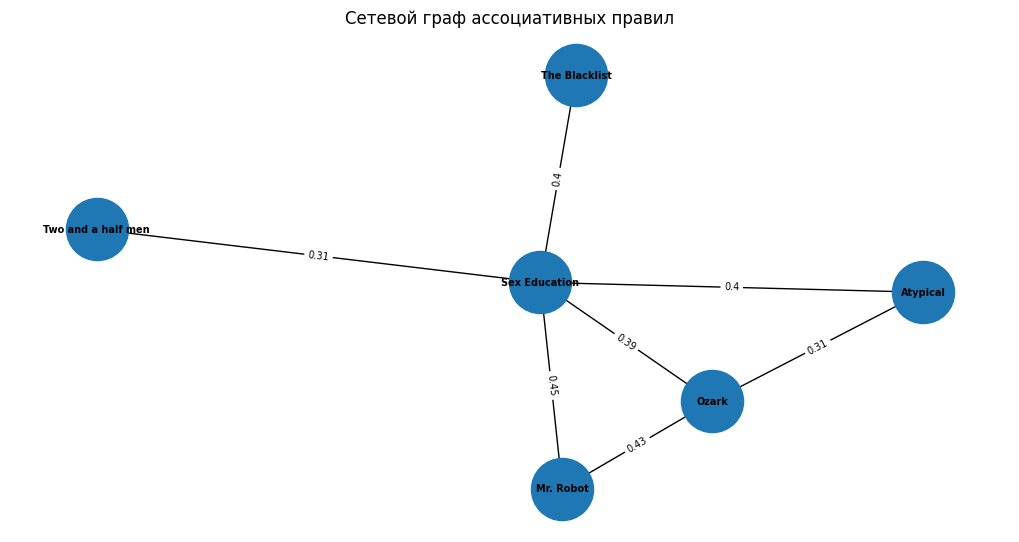

In [1162]:
G = nx.Graph()
for product in rules["antecedents"]:
    G.add_node(product)
for product in rules["consequents"]:
    G.add_node(product)
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=round(row['confidence'],2))
pos = nx.spring_layout(G)
plt.figure(figsize=(10,5))
nx.draw(G, pos,  with_labels=True, node_size=2000, font_size=7, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title('Сетевой граф ассоциативных правил')
plt.tight_layout()
plt.show()

### 4.3 Визуализации ассоциативных правил и метрик
Для визуализации ассоциативных правил удобно использовать heat map, где на осях X и Y откладываются antecedents и consequents, а цвет отражает показатель confidence или lift. Это позволяет быстро увидеть, какие пары сериалов связаны сильнее.

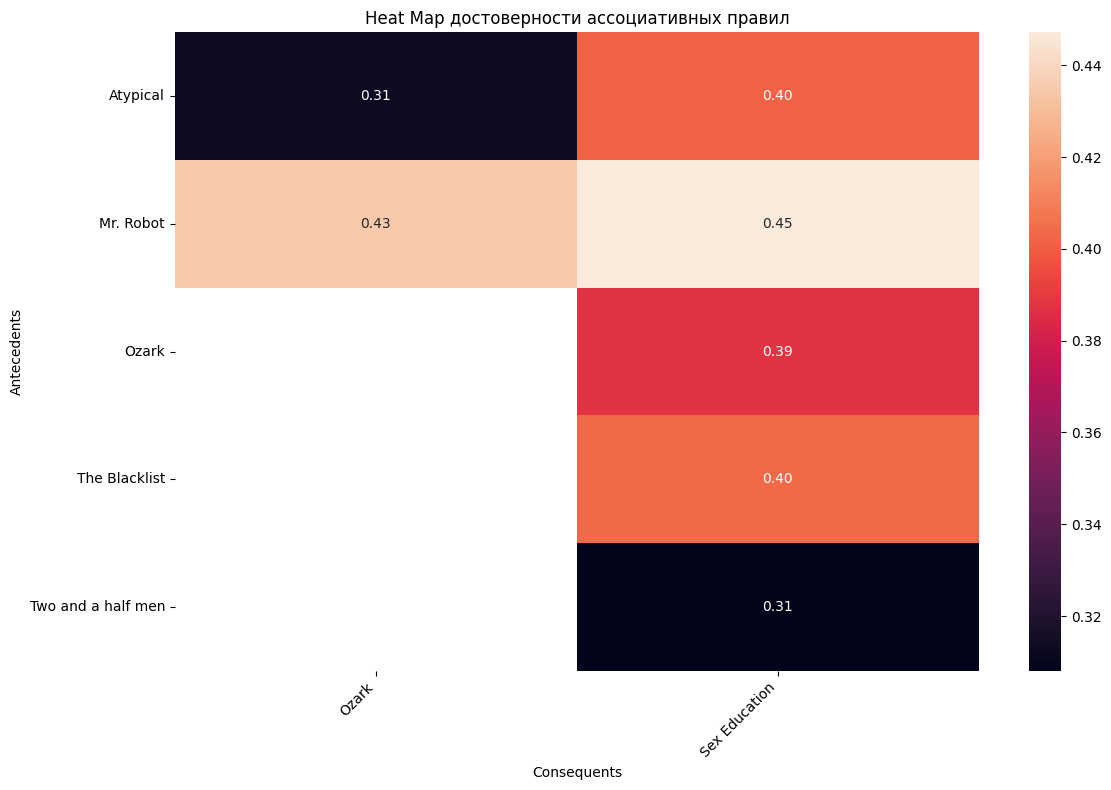

consequents,Ozark,Sex Education
antecedents,,
Atypical,0.312684,0.401180
Mr. Robot,0.434906,0.447170
Ozark,NaN,0.387853
The Blacklist,NaN,0.403543
Two and a half men,NaN,0.308038


In [1163]:
heat_data = rules.pivot(index='antecedents', columns='consequents', values='confidence')

plt.figure(figsize=(12,8))
sns.heatmap(heat_data, annot=True,  fmt=".2f",)
plt.title('Heat Map достоверности ассоциативных правил')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
heat_data

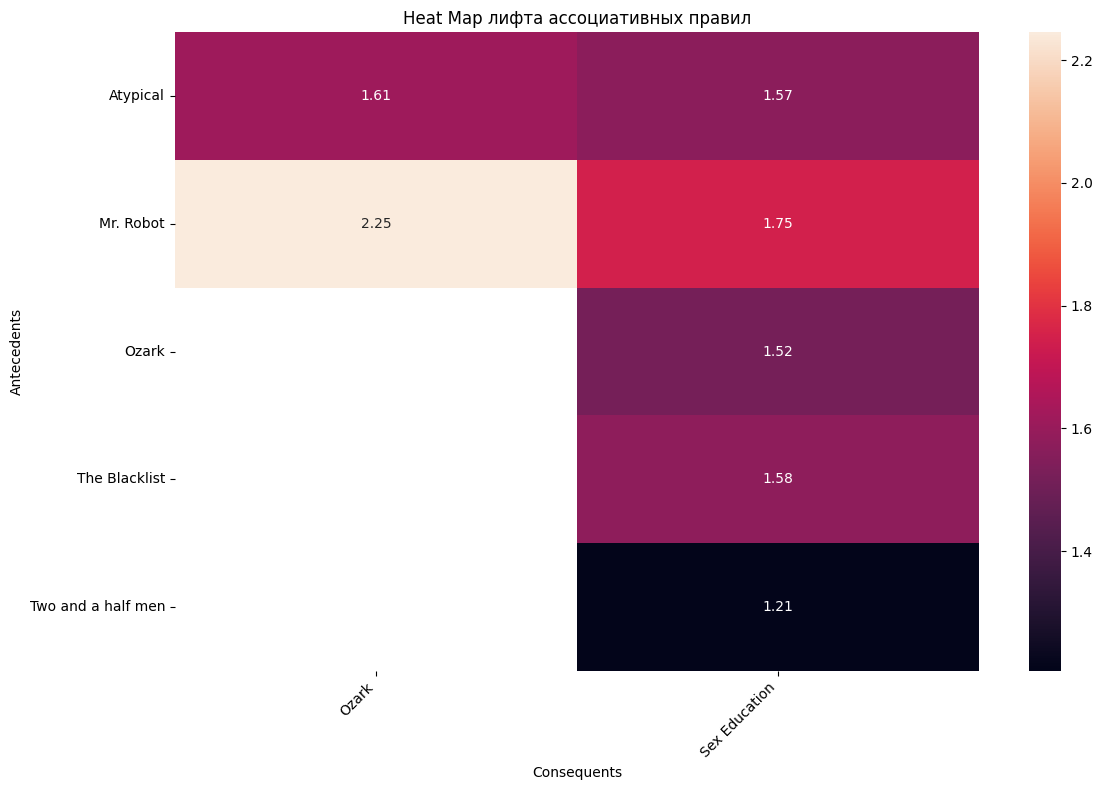

consequents,Ozark,Sex Education
antecedents,,
Atypical,1.614231,1.569412
Mr. Robot,2.245198,1.749324
Ozark,NaN,1.517277
The Blacklist,NaN,1.578658
Two and a half men,NaN,1.205043


In [1164]:
heat_data = rules.pivot(index='antecedents', columns='consequents', values='lift')

plt.figure(figsize=(12,8))
sns.heatmap(heat_data, annot=True,  fmt=".2f",)
plt.title('Heat Map лифта ассоциативных правил')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
heat_data

Тепловая карта наглядно демонстрирует, для каких ассоциативных правил значения лифта самые высокие .